In [71]:
import torch 
import torchvision
import torch.nn as nn 
import torch.nn.functional as F 
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import timm
from torch.optim.lr_scheduler import CosineAnnealingLR
import pandas as pd 
import numpy as np 
import seaborn as sns 
import os 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
import zipfile 
from torchvision import datasets, transforms
from torchsummary import summary 
from torch.utils.data import Dataset
from PIL import Image
import glob
from torchvision.utils import make_grid
from torch.utils.data import Subset
import shutil
from pathlib import Path
import optuna

### Importing necessary datasets


In [ ]:
import kagglehub


path = kagglehub.dataset_download("ajitkumarsenthil/metadata")

print("Path to dataset files:", path)



In [ ]:

path = kagglehub.dataset_download("ajitkumarsenthil/dataset1")

print("Path to dataset files:", path)

In [ ]:


path = kagglehub.dataset_download("ajitkumarsenthil/dataset2")

print("Path to dataset files:", path)

In [ ]:

path = kagglehub.dataset_download("ajitkumarsenthil/dataset3")

print("Path to dataset files:", path)

### Merging the datafolders into a single folder

In [7]:

SOURCE_FOLDERS = [
    '/kaggle/input/dataset1/imgs_part_1/',
    '/kaggle/input/dataset2/imgs_part_2/',
    '/kaggle/input/dataset3/imgs_part_3/'
]

# 2. The single folder where you want all images to end up
DESTINATION_FOLDER = '/kaggle/working/all_images/'



# Create the destination folder if it doesn't exist
os.makedirs(DESTINATION_FOLDER, exist_ok=True)

print(f"Merging images into '{DESTINATION_FOLDER}'...")

total_files_copied = 0

for folder in SOURCE_FOLDERS:
   
    for filename in os.listdir(folder):
        source_path = os.path.join(folder, filename)
        destination_path = os.path.join(DESTINATION_FOLDER, filename)

       
        shutil.copy(source_path, destination_path)
        total_files_copied += 1

print(f"\n✅ All folders merged. Copied a total of {total_files_copied} images.")

Merging images into '/kaggle/working/all_images/'...

✅ All folders merged. Copied a total of 2298 images.


### Assigning label index to the Image data respectively according to the metadata

In [8]:

METADATA_FILE = '/kaggle/input/metadata/metadata.csv'
SOURCE_IMAGE_DIR = '/kaggle/working/all_images/' 
LABELED_IMAGE_DIR = '/kaggle/working/labeled_images2/'



def categorize_images(metadata_path, source_dir, dest_dir):
    """
    Reads a metadata CSV and copies images from a source directory
    to labeled subdirectories in a destination directory.
    """
    try:
        df = pd.read_csv(metadata_path)
    except FileNotFoundError:
        print(f"Error: The file '{metadata_path}' was not found.")
        return

    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)
        print(f"Created directory: {dest_dir}")

    labels = df['diagnostic'].unique()
    for label in labels:
        label_path = os.path.join(dest_dir, label)
        if not os.path.exists(label_path):
            os.makedirs(label_path)

    images_copied = 0
    images_not_found = 0

    print("\nStarting image categorization...")
    for index, row in df.iterrows():
        image_id = row['img_id']
        label = row['diagnostic']

        source_image_path = os.path.join(source_dir, image_id)
        dest_image_path = os.path.join(dest_dir, label, image_id)

        if os.path.exists(source_image_path):
            # --- The key change is here: use copy instead of move ---
            shutil.copy(source_image_path, dest_image_path)
            images_copied += 1
        else:
            images_not_found += 1

    print("\n--- Categorization Complete ---")
    print(f" Successfully copied {images_copied} images.")
    print(f" Could not find {images_not_found} images listed in the metadata file.")

In [9]:
categorize_images(METADATA_FILE, SOURCE_IMAGE_DIR, LABELED_IMAGE_DIR)

Created directory: /kaggle/working/labeled_images2/

Starting image categorization...

--- Categorization Complete ---
 Successfully copied 2298 images.
 Could not find 0 images listed in the metadata file.


In [10]:

# Load the dataset
df = pd.read_csv('/kaggle/input/metadata/metadata.csv')

# --- Data Cleaning ---

# For numerical columns, fill missing values with the mean
for col in ['diameter_1', 'diameter_2', 'fitspatrick']:
    df[col].fillna(df[col].mean(), inplace=True)

# For categorical columns, fill missing values with the most frequent value (mode)
for col in ['smoke', 'drink', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Drop columns that are less likely to be useful or have too many unique/missing values
df.drop(columns=['background_father', 'background_mother', 'pesticide'], inplace=True)


print(" Data has been cleaned. Missing values handled.")
print("\n--- First 5 Rows of Cleaned Data ---")
print(df.head())

✅ Data has been cleaned. Missing values handled.

--- First 5 Rows of Cleaned Data ---
  patient_id  lesion_id  smoke  drink  age  gender  skin_cancer_history  \
0   PAT_1516       1765  False  False    8  FEMALE                False   
1     PAT_46        881  False  False   55  FEMALE                 True   
2   PAT_1545       1867  False  False   77  FEMALE                False   
3   PAT_1989       4061  False  False   75  FEMALE                False   
4    PAT_684       1302  False   True   79    MALE                 True   

   cancer_history  has_piped_water  has_sewage_system  ...  diameter_2  \
0            True             True               True  ...    8.852209   
1            True             True               True  ...    5.000000   
2            True             True               True  ...    8.852209   
3            True             True               True  ...    8.852209   
4           False            False              False  ...    5.000000   

  diagnostic   it

/tmp/ipykernel_35/644525960.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_35/644525960.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

In [11]:
# --- Descriptive Statistics ---

print("\n--- Main Dataset Statistics ---")
print(df.describe(include='all'))


--- Main Dataset Statistics ---
       patient_id    lesion_id  smoke  drink          age  gender  \
count        2298  2298.000000   2298   2298  2298.000000    2298   
unique       1373          NaN      2      2          NaN       2   
top       PAT_330          NaN  False  False          NaN  FEMALE   
freq           10          NaN   2096   1930          NaN    1557   
mean          NaN  1529.933856    NaN    NaN    60.464752     NaN   
std           NaN  1196.285644    NaN    NaN    15.894866     NaN   
min           NaN     6.000000    NaN    NaN     6.000000     NaN   
25%           NaN   720.500000    NaN    NaN    52.000000     NaN   
50%           NaN  1297.000000    NaN    NaN    62.000000     NaN   
75%           NaN  1782.750000    NaN    NaN    72.000000     NaN   
max           NaN  4820.000000    NaN    NaN    94.000000     NaN   

       skin_cancer_history cancer_history has_piped_water has_sewage_system  \
count                 2298           2298            2298  

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [12]:
print(df.isnull().sum())

patient_id             0
lesion_id              0
smoke                  0
drink                  0
age                    0
gender                 0
skin_cancer_history    0
cancer_history         0
has_piped_water        0
has_sewage_system      0
fitspatrick            0
region                 0
diameter_1             0
diameter_2             0
diagnostic             0
itch                   0
grew                   0
hurt                   0
changed                0
bleed                  0
elevation              0
img_id                 0
biopsed                0
dtype: int64


## **Distribution of Skin Lesion Diagnoses plot**

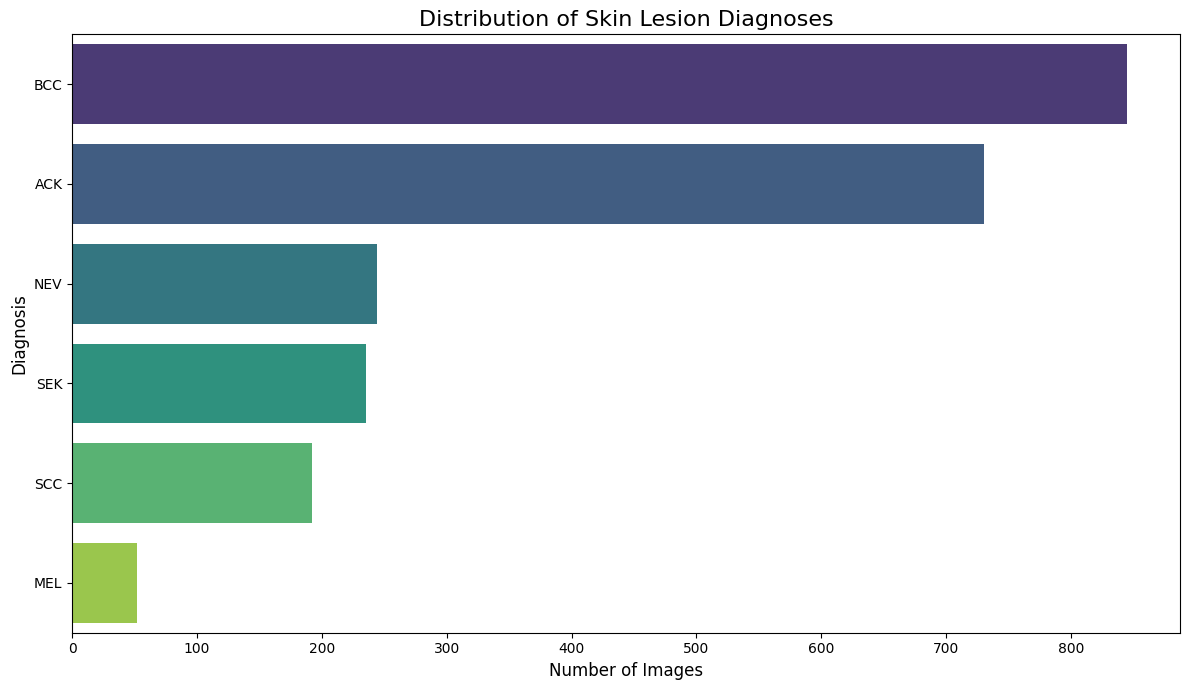

In [13]:
plt.figure(figsize=(12, 7))
sns.countplot(y=df['diagnostic'], order = df['diagnostic'].value_counts().index, palette="viridis")
plt.title('Distribution of Skin Lesion Diagnoses', fontsize=16)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Diagnosis', fontsize=12)
plt.tight_layout()
plt.show()

#### the above chart shows the number of images for different types of skin lesion diagnoses in a dataset.Basal Cell Carcinoma (BCC) is the most common diagnosis, while Melanoma (MEL) is the least common. The number of images for each diagnosis is unequal, indicating an imbalanced collection of data.

## **Distribution of Patient Ages plot**

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


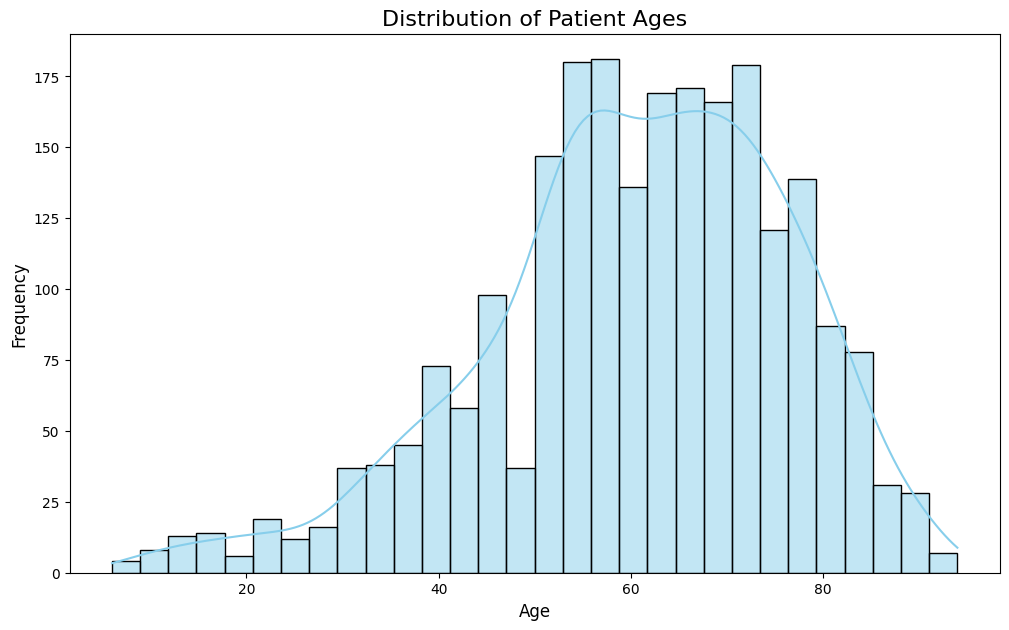

In [14]:
plt.figure(figsize=(12, 7))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Patient Ages', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

### The above histogram shows the frequency of different ages among a group of patients.The data indicates that most patients are between 50 and 80 years old. The highest concentration of patients is in their late 50s and early 60s, while younger patients are much less common in this sample.

## **Frequency of Lesions by Body Region plot**

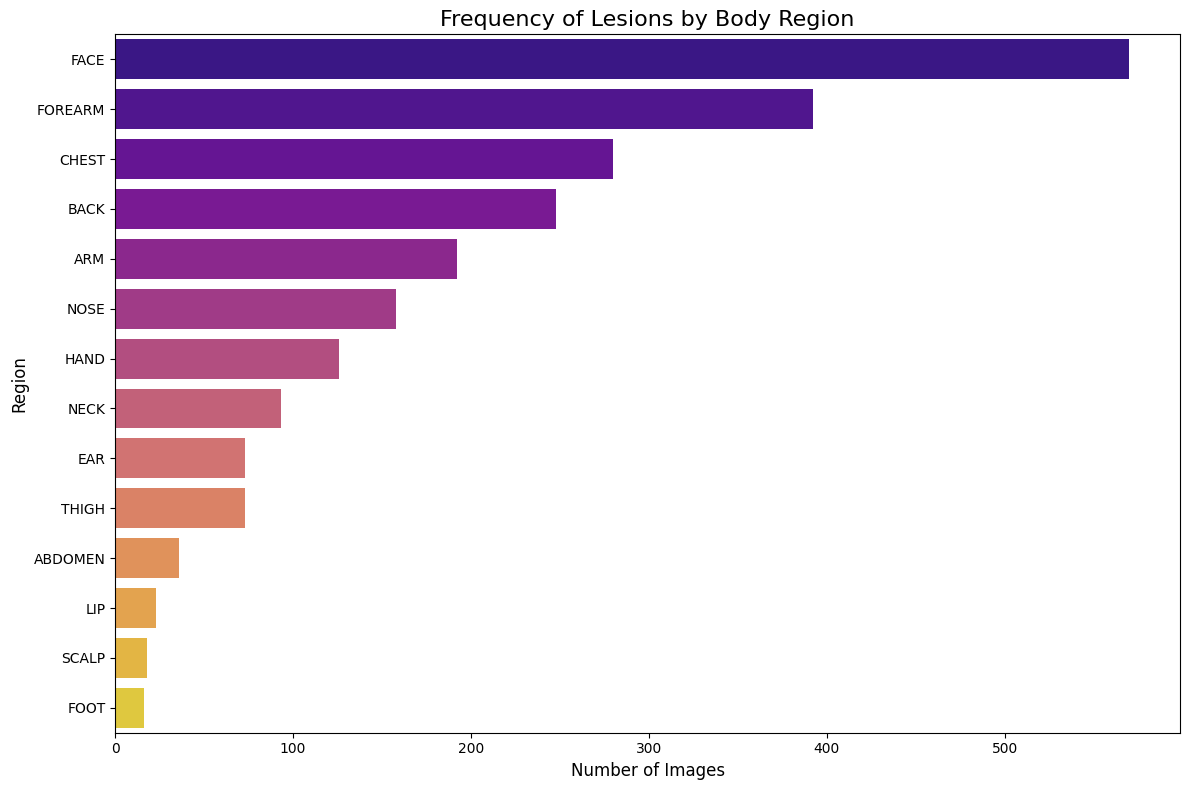

In [15]:
plt.figure(figsize=(12, 8))
sns.countplot(y=df['region'], order=df['region'].value_counts().index, palette="plasma")
plt.title('Frequency of Lesions by Body Region', fontsize=16)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.tight_layout()
plt.show()

## The above chart shows how often skin lesions appear on different parts of the body.The face is the most common location for lesions by a large margin, followed by the forearm. Lesions are least frequent on the abdomen, lip, scalp, and foot.

## ** Lesion Diameter by diagnosis plots**

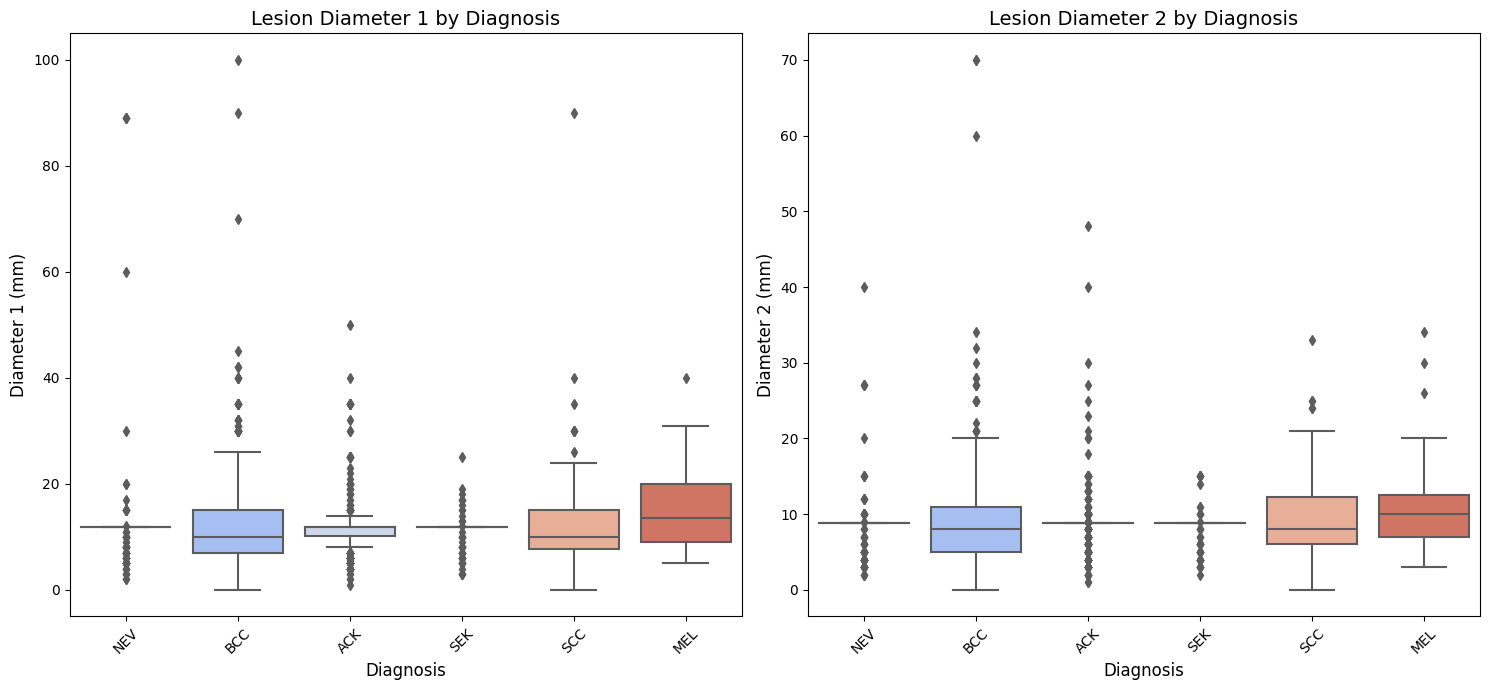

In [16]:
# Plotting both diameters
plt.figure(figsize=(15, 7))

# Diameter 1
plt.subplot(1, 2, 1)
sns.boxplot(x='diagnostic', y='diameter_1', data=df, palette="coolwarm")
plt.title('Lesion Diameter 1 by Diagnosis', fontsize=14)
plt.xlabel('Diagnosis', fontsize=12)
plt.ylabel('Diameter 1 (mm)', fontsize=12)
plt.xticks(rotation=45)

# Diameter 2
plt.subplot(1, 2, 2)
sns.boxplot(x='diagnostic', y='diameter_2', data=df, palette="coolwarm")
plt.title('Lesion Diameter 2 by Diagnosis', fontsize=14)
plt.xlabel('Diagnosis', fontsize=12)
plt.ylabel('Diameter 2 (mm)', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

from the above box plot for diameter1  compares the primary diameter of skin lesions across different diagnoses. On average, Melanoma (MEL) and Squamous Cell Carcinoma (SCC) lesions tend to be larger than other types. Many diagnoses, especially Basal Cell Carcinoma (BCC), show a wide range of sizes, including several very large outliers.

The second plot displays the secondary diameter for the same lesions, showing a very similar pattern to the first plot. Again, MEL and SCC typically have larger diameters compared to the other conditions. While the overall size measurements are slightly smaller here, the relationship between diagnosis and lesion size remains consistent.

## **SAMPLE IMAGES DISPLAY**

In [31]:
def plot_image_grid(data_loader, class_names, num_images=20):
 
    images, labels = next(iter(data_loader))

  
    num_images = min(num_images, len(images))
    rows = int(np.ceil(num_images / 5))
    cols = 5


    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten() 

    for i in range(num_images):

        img = images[i]
       
        npimg = img.numpy()

        ax = axes[i]
        ax.imshow(np.transpose(npimg, (1, 2, 0)))
        ax.set_title(class_names[labels[i]])
        ax.axis('off')


    for j in range(num_images, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

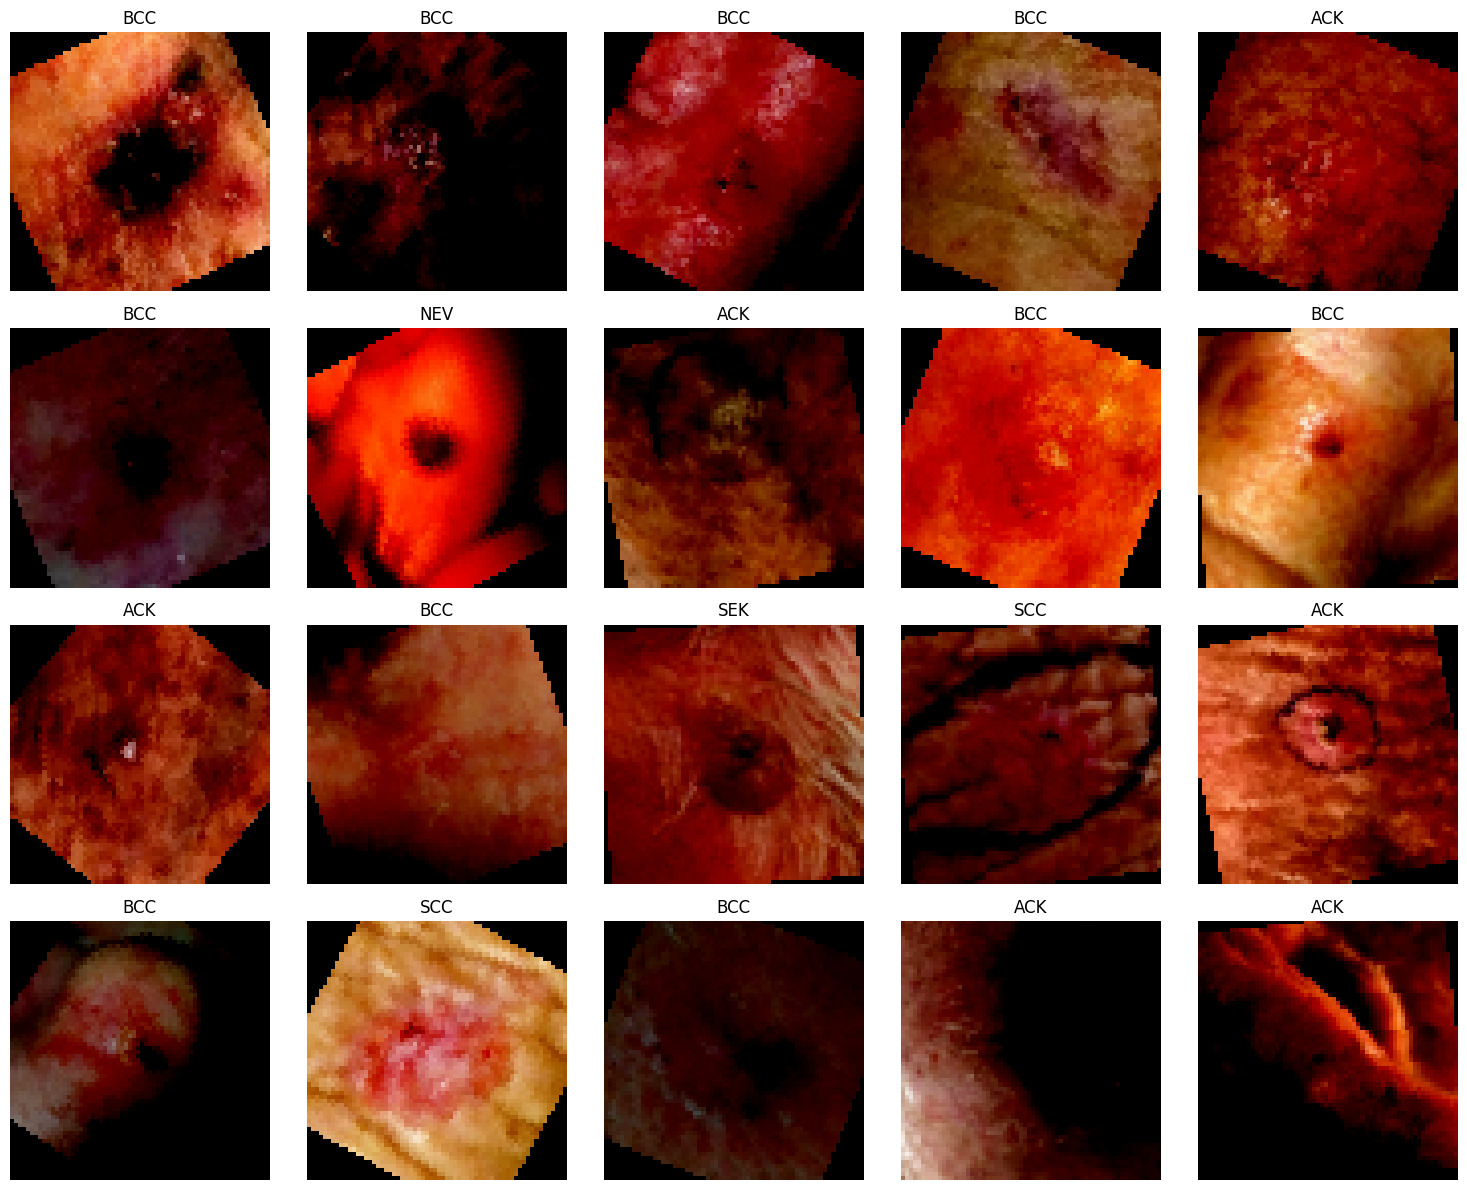

In [32]:
plot_image_grid(train_loader, class_names, num_images=20)

### Defining the train , validation and test dataset split 

In [19]:


train_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomRotation(40),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])])

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(), 
    transforms.Normalize(mean = [0.5]*3 , std = [0.5]*3)
])

In [20]:
dataset = datasets.ImageFolder(root="/kaggle/working/labeled_images2/", transform=transform)

class_names = dataset.classes

In [21]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size 

# 3. Split the dataset
# Use a fixed generator for reproducibility
train_subset, val_subset, test_subset = random_split(
    dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42)
)


train_subset.dataset.transform = train_transform

In [22]:
print("Setting up data loaders...")

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True
)

validation_loader = DataLoader(
    val_subset,
    batch_size=32,
    shuffle=False 
)

test_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False
)

print("\n All Done!")
print(f"Total images: {len(dataset)}")
print(f"Training images: {len(train_subset)}")
print(f"Validation images: {len(val_subset)}")
print(f"Test images: {len(test_subset)}")
print(f"\nThere are {len(class_names)} classes: {class_names}")

Setting up data loaders...

 All Done!
Total images: 2298
Training images: 1838
Validation images: 229
Test images: 231

There are 6 classes: ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']


In [28]:
if torch.cuda.device_count() > 1:
  print(f"Using {torch.cuda.device_count()} GPUs!")
 

# Move the model to the device (it will be distributed automatically)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


### Lets define our baseline model 


In [33]:
class Cancerdetector(nn.Module):
    def __init__(self, num_classes):
        super(Cancerdetector,self).__init__()
    
        assert num_classes is not None 
        assert num_classes > 1
    
        self.num_classes = num_classes
    
        self.block1 = nn.Sequential(
                nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
                nn.BatchNorm2d(16),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )
       
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
    
       
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
    
   
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=64 * 8 * 8, out_features=512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features=512, out_features=self.num_classes)
        )

    def forward(self, x):
       
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        
        return x

In [34]:
model = Cancerdetector(num_classes = 6)
model.to(device)

Cancerdetector(
  (block1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_f

In [35]:
summary(model, input_size =(3,64,64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             448
       BatchNorm2d-2           [-1, 16, 64, 64]              32
              ReLU-3           [-1, 16, 64, 64]               0
         MaxPool2d-4           [-1, 16, 32, 32]               0
            Conv2d-5           [-1, 32, 32, 32]           4,640
       BatchNorm2d-6           [-1, 32, 32, 32]              64
              ReLU-7           [-1, 32, 32, 32]               0
         MaxPool2d-8           [-1, 32, 16, 16]               0
            Conv2d-9           [-1, 64, 16, 16]          18,496
      BatchNorm2d-10           [-1, 64, 16, 16]             128
             ReLU-11           [-1, 64, 16, 16]               0
        MaxPool2d-12             [-1, 64, 8, 8]               0
          Flatten-13                 [-1, 4096]               0
           Linear-14                  [

In [36]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr = 0.0002)
scheduler = ReduceLROnPlateau(optimizer,mode='min',factor=0.1,patience=5,verbose=True)


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [37]:
def training_phase(model, train_loader, optimizer, loss_function, device):
    
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images =  images.to(device)
        labels = labels.to(device)

       
        outputs = model(images)
        loss = loss_function(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    accuracy = correct / total
    return train_loss, accuracy




    
    

In [38]:
def validation_phase(model, validation_loader, loss_function, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in validation_loader:
            images = images.to(device)
            labels =  labels.to(device)
            outputs = model(images)
            loss = loss_function(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(validation_loader)
    accuracy = correct / total
    
    return val_loss, accuracy


In [39]:
def testing_phase(model, test_loader, device, loss_function):
    
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)

            loss = loss_function(outputs, labels)
            total_loss += loss.item() * labels.size(0)  

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = total_loss / total
    accuracy = correct / total

    
    return test_loss, accuracy, all_preds, all_labels


In [40]:

from torch import manual_seed
import time


torch.manual_seed(42)
np.random.seed(42)


best_Acc = 0 
best_epoch = -1
best_val_acc = 0  


epochs = 50 
best_val = np.inf or float('inf')
History_ = [] 
batch_size = 64

train_Data_loader = DataLoader(train_subset, batch_size = batch_size, shuffle = True)
val_Data_loader = DataLoader(val_subset, batch_size = batch_size, shuffle = False)
test_Data_loader = DataLoader(test_subset, batch_size = batch_size, shuffle = False)

start_time = time.time() 

for epoch in range(epochs):
    train_loss_, train_accuracy_ = training_phase(model, train_Data_loader, optimizer, loss_function ,device=device )
    val_loss_, val_accuracy_ = validation_phase(model, val_Data_loader, loss_function , device = device)
    History_.append((train_loss_, train_accuracy_, val_loss_, val_accuracy_))
    
    scheduler.step(val_loss_)

    if val_loss_  < best_val:
        best_val = val_loss_
        torch.save(model.state_dict(), 'baseline_Cnn_model.pth')
    
    if train_accuracy_ > best_Acc:
        best_Acc = train_accuracy_
        best_epoch = epoch + 1
    
    if val_accuracy_ > best_val_acc:
        best_val_acc = val_accuracy_
        best_epoch_val = epoch + 1

    if epoch % 2 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss_:.4f}, Train Accuracy: {train_accuracy_:.4f}, Val Loss: {val_loss_:.4f}, Val Accuracy: {val_accuracy_:.4f}")

end_time = time.time()
duration = end_time - start_time
print(f"Total training time: {duration:.2f} seconds")  
print(f"Best training accuracy of {best_Acc:.4f} was achieved in epoch {best_epoch} || Best validation accuracy of {best_val_acc:.4f} was achieved in epoch {best_epoch_val}")







  

  











Epoch 1/50, Train Loss: 1.5633, Train Accuracy: 0.3825, Val Loss: 1.5060, Val Accuracy: 0.3581
Epoch 3/50, Train Loss: 1.3095, Train Accuracy: 0.5065, Val Loss: 1.2160, Val Accuracy: 0.5590
Epoch 5/50, Train Loss: 1.1818, Train Accuracy: 0.5631, Val Loss: 1.1095, Val Accuracy: 0.5633
Epoch 7/50, Train Loss: 1.1337, Train Accuracy: 0.5707, Val Loss: 1.0678, Val Accuracy: 0.6026
Epoch 9/50, Train Loss: 1.0886, Train Accuracy: 0.6028, Val Loss: 1.0596, Val Accuracy: 0.5983
Epoch 11/50, Train Loss: 1.0820, Train Accuracy: 0.6034, Val Loss: 1.0227, Val Accuracy: 0.6157
Epoch 13/50, Train Loss: 1.0409, Train Accuracy: 0.6153, Val Loss: 0.9993, Val Accuracy: 0.6201
Epoch 15/50, Train Loss: 1.0260, Train Accuracy: 0.6148, Val Loss: 1.0134, Val Accuracy: 0.6376
Epoch 17/50, Train Loss: 1.0172, Train Accuracy: 0.6126, Val Loss: 1.0151, Val Accuracy: 0.6376
Epoch 19/50, Train Loss: 1.0003, Train Accuracy: 0.6306, Val Loss: 1.0339, Val Accuracy: 0.6288
Epoch 21/50, Train Loss: 0.9659, Train Accura

In [41]:
test_loss, test_accuracy, y_pred, y_true = testing_phase(model, test_loader, device,loss_function)

test_history = []
test_history.append((test_loss,test_accuracy))

print(f" Test loss : {test_loss} || Test accuracy : {test_accuracy}" )

 Test loss : 0.9896403275010905 || Test accuracy : 0.6190476190476191


## Our baseline model has achieved an accuracy of 61.90%

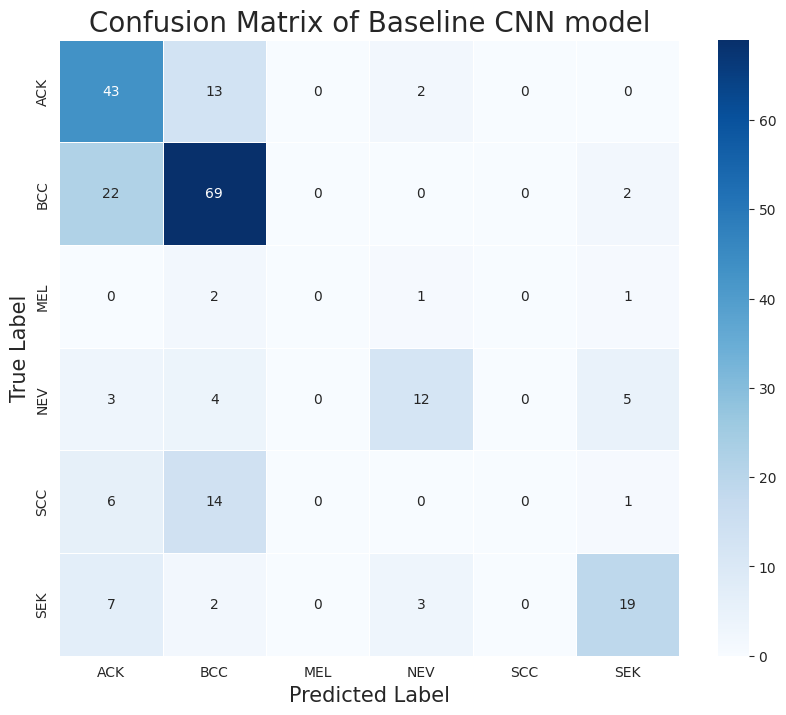

In [95]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

    
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)


plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_df,
    annot=True,     
    fmt='d',        
    cmap='Blues',   
    linewidths=.5
)

plt.title('Confusion Matrix of Baseline CNN model', fontsize=20)
plt.ylabel('True Label', fontsize=15)
plt.xlabel('Predicted Label', fontsize=15)
plt.show()

#### The above confusion matrix shows the performance of a skin lesion classification model.The model is most effective at identifying Basal Cell Carcinoma (BCC), correctly classifying 69 cases. However, it performs very poorly on critical diagnoses, failing to correctly identify a single case of Melanoma (MEL) or Squamous Cell Carcinoma (SCC). There is also significant confusion between different lesion types, especially between ACK and BCC.

In [100]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

         ACK       0.53      0.74      0.62        58
         BCC       0.66      0.74      0.70        93
         MEL       0.00      0.00      0.00         4
         NEV       0.67      0.50      0.57        24
         SCC       0.00      0.00      0.00        21
         SEK       0.68      0.61      0.64        31

    accuracy                           0.62       231
   macro avg       0.42      0.43      0.42       231
weighted avg       0.56      0.62      0.58       231



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



###
from the classification report ,the model has an overall accuracy of 62%, but it completely fails on the most critical classes, with zero scores for detecting Melanoma (MEL) and Squamous Cell Carcinoma (SCC). While it performs best on Basal Cell Carcinoma (BCC) with an f1-score of 0.70, the low average scores show the model is not reliable for practical use.

## **Defining our improved model with CBAM attention and including pretrained Efficient-net**

In [42]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_attn = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
            nn.Sigmoid()
        )
        self.spatial_attn = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        ca = self.channel_attn(x) * x
        sa_in = torch.cat([torch.mean(ca, dim=1, keepdim=True), torch.max(ca, dim=1, keepdim=True)[0]], dim=1)
        sa = self.spatial_attn(sa_in)
        return ca * sa


class HybridCancerDetectorNet(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        assert num_classes is not None and num_classes > 1
        assert pretrained  is True 

        self.num_classes = num_classes
        
        self.backbone = timm.create_model('efficientnet_b0', pretrained=pretrained, features_only=True)
        
       
        num_features = self.backbone.feature_info[-1]['num_chs']
        
       
        self.attention = CBAM(num_features)
        
        # 3. Create a new classifier head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)), 
            nn.Flatten(),
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Pass input through the backbone to get feature maps
        features = self.backbone(x)
        
        # Get the features from the final block
        last_features = features[-1]
        
        # Apply the attention mechanism
        refined_features = self.attention(last_features)
        
        # Pass the refined features to the classifier
        output = self.classifier(refined_features)
        
        return output


In [43]:
device2 = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [44]:
Model2 = HybridCancerDetectorNet(num_classes = 6, pretrained=True )
Model2.to(device2)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

HybridCancerDetectorNet(
  (backbone): EfficientNetFeatures(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
  

In [45]:
summary(Model2,input_size=(3,64,64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             864
          Identity-2           [-1, 32, 32, 32]               0
              SiLU-3           [-1, 32, 32, 32]               0
    BatchNormAct2d-4           [-1, 32, 32, 32]              64
            Conv2d-5           [-1, 32, 32, 32]             288
          Identity-6           [-1, 32, 32, 32]               0
              SiLU-7           [-1, 32, 32, 32]               0
    BatchNormAct2d-8           [-1, 32, 32, 32]              64
          Identity-9           [-1, 32, 32, 32]               0
           Conv2d-10              [-1, 8, 1, 1]             264
             SiLU-11              [-1, 8, 1, 1]               0
           Conv2d-12             [-1, 32, 1, 1]             288
          Sigmoid-13             [-1, 32, 1, 1]               0
    SqueezeExcite-14           [-1, 32,

In [53]:
loss_function2 = nn.CrossEntropyLoss() 
optimizer2 = optim.AdamW(Model2.parameters(), lr= 1e-4)
scheduler2 = CosineAnnealingLR(
    optimizer2,
    T_max= 50,
    eta_min=1e-6)


In [54]:

from torch import manual_seed
import time


torch.manual_seed(42)
np.random.seed(42)


best_Acc = 0 
best_epoch = -1
best_val_acc = 0  


epochs = 50 
best_val = np.inf or float('inf')
history_ = [] 
batch_size = 64

train_Data_loader_1 = DataLoader(train_subset, batch_size = batch_size, shuffle = True)
val_Data_loader_1 = DataLoader(val_subset, batch_size = batch_size, shuffle = False)



start_time = time.time() 

for epoch in range(epochs):
    train_loss_1, train_accuracy_1 = training_phase(Model2, train_Data_loader_1, optimizer2, loss_function2 ,device=device )
    val_loss_1, val_accuracy_1 = validation_phase(Model2, val_Data_loader_1, loss_function2 , device = device)
    history_.append((train_loss_1, train_accuracy_1, val_loss_1, val_accuracy_1))
    
    scheduler2.step()

    if val_loss_1  < best_val:
        best_val = val_loss_1
        torch.save(Model2.state_dict(), 'Improved_Cnn_model.pth')
    
    if train_accuracy_1 > best_Acc:
        best_Acc = train_accuracy_1
        best_epoch = epoch + 1
    
    if val_accuracy_1 > best_val_acc:
        best_val_acc = val_accuracy_1
        best_epoch_val = epoch + 1

    if epoch % 2 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss_1:.4f}, Train Accuracy: {train_accuracy_1:.4f}, Val Loss: {val_loss_1:.4f}, Val Accuracy: {val_accuracy_1:.4f}")

end_time = time.time()
duration = end_time - start_time
print(f"Total training time: {duration:.2f} seconds")  
print(f"Best training accuracy of {best_Acc:.4f} was achieved in epoch {best_epoch} || Best validation accuracy of {best_val_acc:.4f} was achieved in epoch {best_epoch_val}")


Epoch 1/50, Train Loss: 1.6199, Train Accuracy: 0.3553, Val Loss: 1.4179, Val Accuracy: 0.5066
Epoch 3/50, Train Loss: 1.2922, Train Accuracy: 0.5180, Val Loss: 1.1838, Val Accuracy: 0.5633
Epoch 5/50, Train Loss: 1.1218, Train Accuracy: 0.6012, Val Loss: 1.0714, Val Accuracy: 0.6419
Epoch 7/50, Train Loss: 0.9850, Train Accuracy: 0.6605, Val Loss: 0.9960, Val Accuracy: 0.6245
Epoch 9/50, Train Loss: 0.9078, Train Accuracy: 0.6714, Val Loss: 0.9518, Val Accuracy: 0.6594
Epoch 11/50, Train Loss: 0.8363, Train Accuracy: 0.6948, Val Loss: 0.8644, Val Accuracy: 0.6725
Epoch 13/50, Train Loss: 0.7878, Train Accuracy: 0.7193, Val Loss: 0.8326, Val Accuracy: 0.7074
Epoch 15/50, Train Loss: 0.7436, Train Accuracy: 0.7356, Val Loss: 0.8622, Val Accuracy: 0.6507
Epoch 17/50, Train Loss: 0.6925, Train Accuracy: 0.7590, Val Loss: 0.8475, Val Accuracy: 0.6900
Epoch 19/50, Train Loss: 0.6646, Train Accuracy: 0.7622, Val Loss: 0.8386, Val Accuracy: 0.7205
Epoch 21/50, Train Loss: 0.6374, Train Accura

In [70]:
test_Data_loader_1 = DataLoader(test_subset, batch_size = 128, shuffle = False)
test_loss1, test_accuracy1, y_pred1, y_true1 = testing_phase(Model2, test_Data_loader_1, device,loss_function2)

test_history1 = []
test_history1.append((test_loss1,test_accuracy1))

print(f" Test loss : {test_loss1:.3f} || Test accuracy : {test_accuracy1 * 100:.3f}%" )

 Test loss : 0.867 || Test accuracy : 70.130%


#### our Improvized model has achieved around 70.13% accuracy 


### Now we will implement hyperparameter tuning through Optuna 


In [74]:

train_Data_loader3 = DataLoader(train_subset, batch_size = 64, shuffle = True)
val_Data_loader3 = DataLoader(val_subset, batch_size = 64, shuffle = False)

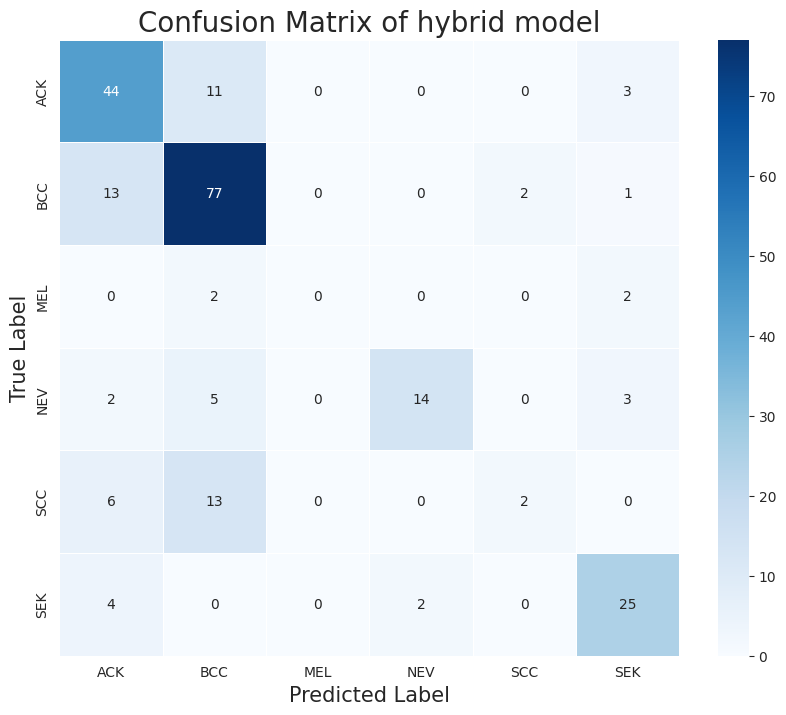

In [94]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true1, y_pred1)

    
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)


plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_df,
    annot=True,     
    fmt='d',        
    cmap='Blues',   
    linewidths=.5
)

plt.title('Confusion Matrix of hybrid model', fontsize=20)
plt.ylabel('True Label', fontsize=15)
plt.xlabel('Predicted Label', fontsize=15)
plt.show()

#### The above confusion matrix evaluates the performance of a hybrid model for classifying skin lesions.The model shows strong performance for Basal Cell Carcinoma (BCC), correctly identifying 77 cases. It also does reasonably well with Actinic Keratosis (ACK) and Seborrheic Keratosis (SEK). However, the model completely fails to identify Melanoma (MEL) and continues to misclassify most Squamous Cell Carcinoma (SCC) cases, showing persistent weaknesses with critical diagnoses.

In [98]:
report = classification_report(y_true1,y_pred1, target_names=class_names)
print(report)

              precision    recall  f1-score   support

         ACK       0.64      0.76      0.69        58
         BCC       0.71      0.83      0.77        93
         MEL       0.00      0.00      0.00         4
         NEV       0.88      0.58      0.70        24
         SCC       0.50      0.10      0.16        21
         SEK       0.74      0.81      0.77        31

    accuracy                           0.70       231
   macro avg       0.58      0.51      0.51       231
weighted avg       0.68      0.70      0.67       231



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


#### From the classification report above we can infer that the model achieves an overall accuracy of 70% and shows strong performance for Basal Cell Carcinoma (BCC) and Seborrheic Keratosis (SEK), both with an f1-score of 0.77. However, it completely fails to identify Melanoma (MEL) and performs very poorly on Squamous Cell Carcinoma (SCC), with an f1-score of only 0.16. This indicates the model is unreliable for detecting some of the most critical types of skin cancer.

In [78]:

from tqdm.auto import tqdm

# --- This objective function is now corrected ---
def objective(trial):
    """
    This is the function Optuna will optimize.
    A 'trial' represents a single run with a specific set of hyperparameters.
    """
    # --- Define the Hyperparameter Search Space ---
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout", 0.2, 0.6)
    optimizer_name = trial.suggest_categorical("optimizer3", ["AdamW", "SGD"])

    # ---  Build the Model with the Suggested Hyperparameters ---
    model3 = HybridCancerDetectorNet(num_classes=6, pretrained=True)
    model3.classifier[-2] = nn.Dropout(p=dropout_rate, inplace= False)
    model3.to(device)

    # Define the optimizer based on the trial's suggestion
    if optimizer_name == "AdamW":
        optimizer3 = optim.AdamW(model3.parameters(), lr=lr)
    else:
        optimizer3 = optim.SGD(model3.parameters(), lr=lr, momentum=0.9)

    loss_function3 = nn.CrossEntropyLoss()
    
    # ---  Training and Validation Loop ---
    num_epochs = 5

    for epoch in range(num_epochs):
        
        # *** FIX 1: The argument order is corrected here ***
        # The optimizer should come before the loss function to match your function's definition.
        _, trainacc = training_phase(model3, train_Data_loader3, optimizer3, loss_function3, device)
        
        val_loss_3, val_accuracy_3 = validation_phase(model3, val_Data_loader3, loss_function3, device)
        
        
        trial.report(val_accuracy_3, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

   
    return val_accuracy_3

# ---  Run the Hyperparameter Search ---
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
print("Starting hyperparameter search...")
study.optimize(objective, n_trials=10)

# ---  Print the Results ---
pruned_trials = study.get_trials(deepcopy=False, states=[optuna.trial.TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[optuna.trial.TrialState.COMPLETE])

print("\n--- Hyperparameter Search Complete ---")
print(f"Number of finished trials: {len(study.trials)}")
print(f"Number of pruned trials: {len(pruned_trials)}")
print(f"Number of complete trials: {len(complete_trials)}")

print("\n✨ Best trial: ✨")
trial = study.best_trial

print(f"  Value (Max Validation Accuracy): {trial.value:.4f}")

print("  Params: ")
for key, value in trial.params.items():
    
    print(f"    {key}: {value}")

[I 2025-07-05 23:28:08,562] A new study created in memory with name: no-name-0ac39c35-43c0-4ab4-b6a3-68c1b06f42a5


Starting hyperparameter search...


[I 2025-07-05 23:34:29,286] Trial 0 finished with value: 0.5502183406113537 and parameters: {'lr': 0.0007281885779397739, 'dropout': 0.47585252241448345, 'optimizer3': 'SGD'}. Best is trial 0 with value: 0.5502183406113537.
[I 2025-07-05 23:40:51,381] Trial 1 finished with value: 0.6331877729257642 and parameters: {'lr': 0.0069332011989793, 'dropout': 0.5288400534642077, 'optimizer3': 'SGD'}. Best is trial 1 with value: 0.6331877729257642.
[I 2025-07-05 23:47:14,082] Trial 2 finished with value: 0.6506550218340611 and parameters: {'lr': 0.0002082530694736166, 'dropout': 0.5691303319427097, 'optimizer3': 'AdamW'}. Best is trial 2 with value: 0.6506550218340611.
[I 2025-07-05 23:53:36,370] Trial 3 finished with value: 0.6681222707423581 and parameters: {'lr': 0.008827309225237374, 'dropout': 0.37394228563923176, 'optimizer3': 'SGD'}. Best is trial 3 with value: 0.6681222707423581.
[I 2025-07-05 23:59:58,338] Trial 4 finished with value: 0.32751091703056767 and parameters: {'lr': 4.154796


--- Hyperparameter Search Complete ---
Number of finished trials: 10
Number of pruned trials: 5
Number of complete trials: 5

✨ Best trial: ✨
  Value (Max Validation Accuracy): 0.6681
  Params: 
    lr: 0.008827309225237374
    dropout: 0.37394228563923176
    optimizer3: SGD


### Model with hyperparameter tuned 

In [79]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_attn = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
            nn.Sigmoid()
        )
        self.spatial_attn = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        ca = self.channel_attn(x) * x
        sa_in = torch.cat([torch.mean(ca, dim=1, keepdim=True), torch.max(ca, dim=1, keepdim=True)[0]], dim=1)
        sa = self.spatial_attn(sa_in)
        return ca * sa


class HybridCancerDetectorNet_hptuned(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        assert num_classes is not None and num_classes > 1
        assert pretrained  is True 

        self.num_classes = num_classes
        
        self.backbone = timm.create_model('efficientnet_b0', pretrained=pretrained, features_only=True)
        
       
        num_features = self.backbone.feature_info[-1]['num_chs']
        
       
        self.attention = CBAM(num_features)
        
        # 3. Create a new classifier head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)), 
            nn.Flatten(),
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3739),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Pass input through the backbone to get feature maps
        features = self.backbone(x)
        
        # Get the features from the final block
        last_features = features[-1]
        
        # Apply the attention mechanism
        refined_features = self.attention(last_features)
        
        # Pass the refined features to the classifier
        output = self.classifier(refined_features)
        
        return output


In [80]:
model3 = HybridCancerDetectorNet_hptuned(num_classes = 6, pretrained=True)
model3.to(device)

HybridCancerDetectorNet_hptuned(
  (backbone): EfficientNetFeatures(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
      

In [89]:
summary(model3, input_size = (3,64,64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             864
          Identity-2           [-1, 32, 32, 32]               0
              SiLU-3           [-1, 32, 32, 32]               0
    BatchNormAct2d-4           [-1, 32, 32, 32]              64
            Conv2d-5           [-1, 32, 32, 32]             288
          Identity-6           [-1, 32, 32, 32]               0
              SiLU-7           [-1, 32, 32, 32]               0
    BatchNormAct2d-8           [-1, 32, 32, 32]              64
          Identity-9           [-1, 32, 32, 32]               0
           Conv2d-10              [-1, 8, 1, 1]             264
             SiLU-11              [-1, 8, 1, 1]               0
           Conv2d-12             [-1, 32, 1, 1]             288
          Sigmoid-13             [-1, 32, 1, 1]               0
    SqueezeExcite-14           [-1, 32,

In [81]:
loss_function_4 = nn.CrossEntropyLoss() 
optimizer_4 = optim.SGD(model3.parameters(), lr=0.008827, momentum=0.9)
scheduler_4 = CosineAnnealingLR(optimizer_4, T_max=100, eta_min=1e-6)

In [82]:

from torch import manual_seed
import time


torch.manual_seed(42)
np.random.seed(42)


best_Acc = 0 
best_epoch = -1
best_val_acc = 0  


epochs = 50 
best_val = np.inf or float('inf')
history_2 = [] 
batch_size = 64

train_Data_loader_2 = DataLoader(train_subset, batch_size = batch_size, shuffle = True)
val_Data_loader_2 = DataLoader(val_subset, batch_size = batch_size, shuffle = False)



start_time = time.time() 

for epoch in range(epochs):
    train_loss_2, train_accuracy_2 = training_phase(model3, train_Data_loader_2, optimizer_4, loss_function_4 ,device=device )
    val_loss_2, val_accuracy_2 = validation_phase(model3, val_Data_loader_2, loss_function_4 , device = device)
    history_2.append((train_loss_2, train_accuracy_2, val_loss_2, val_accuracy_2))
    
    scheduler_4.step()

    if val_loss_2  < best_val:
        best_val = val_loss_2
        torch.save(model3.state_dict(), 'Improved_Cnn_model_hyperparametertuned.pth')
    
    if train_accuracy_2 > best_Acc:
        best_Acc = train_accuracy_2
        best_epoch = epoch + 1
    
    if val_accuracy_2 > best_val_acc:
        best_val_acc = val_accuracy_2
        best_epoch_val = epoch + 1

    if epoch % 2 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss_2:.4f}, Train Accuracy: {train_accuracy_2*100:.3f}, Val Loss: {val_loss_2:.4f}, Val Accuracy: {val_accuracy_2*100:.4f}")

end_time = time.time()
duration = end_time - start_time
print(f"Total training time: {duration:.2f} seconds")  
print(f"Best training accuracy of {best_Acc:.4f} was achieved in epoch {best_epoch} || Best validation accuracy of {best_val_acc:.4f} was achieved in epoch {best_epoch_val}")


Epoch 1/50, Train Loss: 1.4776, Train Accuracy: 42.111, Val Loss: 1.2670, Val Accuracy: 53.7118
Epoch 3/50, Train Loss: 1.0150, Train Accuracy: 63.547, Val Loss: 0.9678, Val Accuracy: 62.4454
Epoch 5/50, Train Loss: 0.8817, Train Accuracy: 68.770, Val Loss: 0.9352, Val Accuracy: 65.0655
Epoch 7/50, Train Loss: 0.7758, Train Accuracy: 71.872, Val Loss: 0.9436, Val Accuracy: 67.6856
Epoch 9/50, Train Loss: 0.6655, Train Accuracy: 75.245, Val Loss: 1.0252, Val Accuracy: 67.6856
Epoch 11/50, Train Loss: 0.6105, Train Accuracy: 77.203, Val Loss: 0.8499, Val Accuracy: 70.7424
Epoch 13/50, Train Loss: 0.5607, Train Accuracy: 79.489, Val Loss: 1.0588, Val Accuracy: 66.3755
Epoch 15/50, Train Loss: 0.4473, Train Accuracy: 83.079, Val Loss: 0.9788, Val Accuracy: 66.8122
Epoch 17/50, Train Loss: 0.3796, Train Accuracy: 85.473, Val Loss: 1.0671, Val Accuracy: 66.3755
Epoch 19/50, Train Loss: 0.3415, Train Accuracy: 87.650, Val Loss: 1.2523, Val Accuracy: 68.5590
Epoch 21/50, Train Loss: 0.2943, Tr

In [85]:
test_Data_loader_2 = DataLoader(test_subset, batch_size = 64, shuffle = False)
test_loss2, test_accuracy2, y_pred2, y_true2 = testing_phase(model3, test_Data_loader_1, device,loss_function_4)

test_history2 = []
test_history2.append((test_loss2,test_accuracy2))

print(f" Test loss : {test_loss2:.3f} || Test accuracy : {test_accuracy2 * 100:.3f}%" )

 Test loss : 1.592 || Test accuracy : 71.861%


## this slightly performs well by 1% over the previous model 

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_35/853615291.py:32: UserWarning: 
The dashes list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=combined_df, x='epoch', y='val_loss', hue='model', style='model', ax=ax1, dashes=[(2,2)], lw=2)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operati

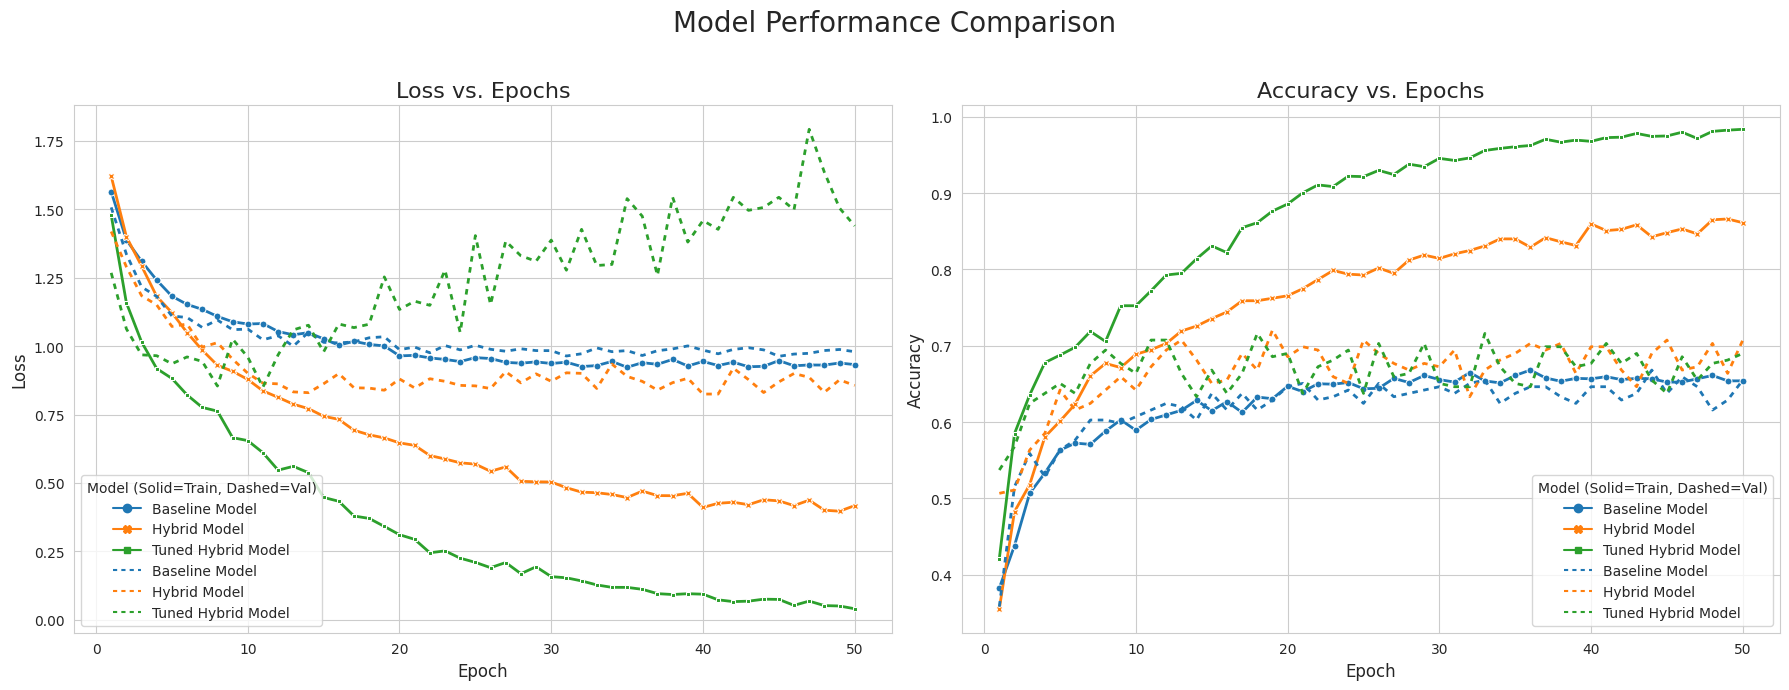

In [88]:


def create_history_df(history, model_name):
    """Converts a history list to a pandas DataFrame."""
  
    df = pd.DataFrame(history, columns=['train_loss', 'train_acc', 'val_loss', 'val_acc'])
 
    df['epoch'] = df.index + 1
   
    df['model'] = model_name
    
    return df


df1 = create_history_df(History_, 'Baseline Model')
df2 = create_history_df(history_, 'Hybrid Model')
df3 = create_history_df(history_2, 'Tuned Hybrid Model')


combined_df = pd.concat([df1, df2, df3], ignore_index=True)


sns.set_style("whitegrid")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Model Performance Comparison', fontsize=20)

# --- Plot 1: Loss (Training vs. Validation) ---
ax1.set_title('Loss vs. Epochs', fontsize=16)
sns.lineplot(data=combined_df, x='epoch', y='train_loss', hue='model', style='model', ax=ax1, dashes=False, markers=True, markersize=5, lw=2)
sns.lineplot(data=combined_df, x='epoch', y='val_loss', hue='model', style='model', ax=ax1, dashes=[(2,2)], lw=2)
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.legend(title='Model (Solid=Train, Dashed=Val)')

# --- Plot 2: Accuracy (Training vs. Validation) ---
ax2.set_title('Accuracy vs. Epochs', fontsize=16)
sns.lineplot(data=combined_df, x='epoch', y='train_acc', hue='model', style='model', ax=ax2, dashes=False, markers=True, markersize=5, lw=2)
sns.lineplot(data=combined_df, x='epoch', y='val_acc', hue='model', style='model', ax=ax2, dashes=[(2,2)], lw=2)
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Accuracy", fontsize=12)
ax2.legend(title='Model (Solid=Train, Dashed=Val)')



plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## from the above performance evaluation metrics: 
we can see that , 
Training Loss (Solid Lines) successfully reduce their error on the data they are trained on.

validation loss:The Hybrid Model (orange) shows the best performance, with its validation loss consistently decreasing. In contrast, the Tuned Hybrid Model's (green) validation loss begins to increase after about 25 epochs, a clear sign of overfitting, meaning it memorized the training data but can't apply its learning to new data effectively.

accuracy :   The Hybrid Model (orange) achieves the highest and most stable validation accuracy, leveling off at approximately 70%. The large gap between the Tuned Hybrid Model's training accuracy (near 100%) and its validation accuracy (around 68%) confirms that it is overfit and does not generalize well compared to the regular Hybrid Model.



## **Our Hybrid model with fine tuned hyperparameters has produced a better result though the test loss is more, it could outperform if the validation and test dataset has more image**

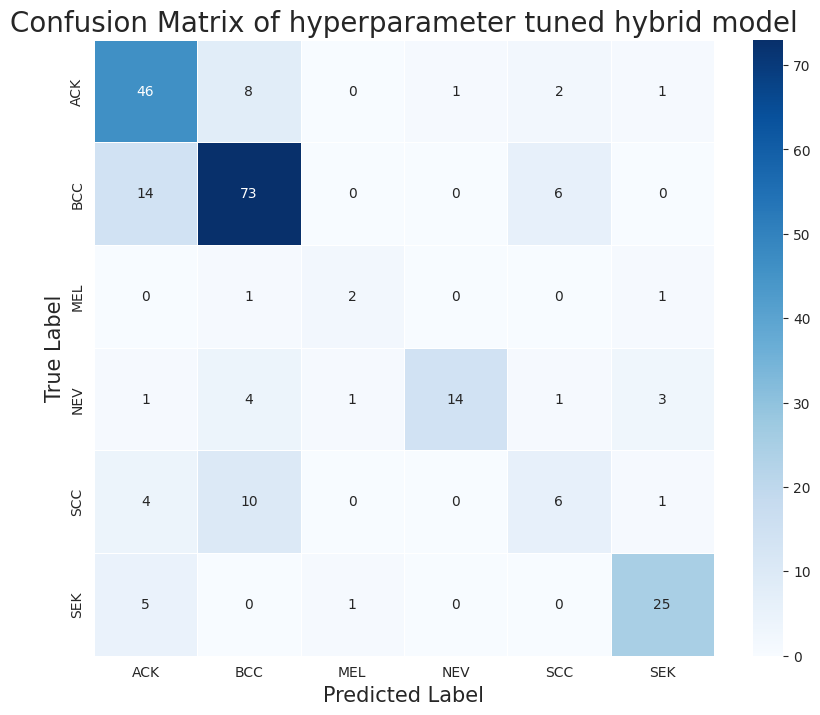

In [93]:


cm = confusion_matrix(y_true2, y_pred2)

    
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)


plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_df,
    annot=True,     
    fmt='d',        
    cmap='Blues',   
    linewidths=.5
)

plt.title('Confusion Matrix of hyperparameter tuned hybrid model', fontsize=20)
plt.ylabel('True Label', fontsize=15)
plt.xlabel('Predicted Label', fontsize=15)
plt.show()

### This confusion matrix evaluates a hyperparameter-tuned hybrid model.This model shows a significant improvement, as it is the first to correctly identify two cases of Melanoma (MEL). While it maintains strong performance for Basal Cell Carcinoma (BCC), it still performs poorly on Squamous Cell Carcinoma (SCC), frequently misclassifying it as other lesions.

In [99]:
from sklearn.metrics import classification_report

report = classification_report(y_true2,y_pred2, target_names=class_names)
print(report)

              precision    recall  f1-score   support

         ACK       0.66      0.79      0.72        58
         BCC       0.76      0.78      0.77        93
         MEL       0.50      0.50      0.50         4
         NEV       0.93      0.58      0.72        24
         SCC       0.40      0.29      0.33        21
         SEK       0.81      0.81      0.81        31

    accuracy                           0.72       231
   macro avg       0.68      0.63      0.64       231
weighted avg       0.72      0.72      0.71       231



### From the classification report above we can infer that the model achieves a respectable overall accuracy of 72% and shows a significant breakthrough by achieving an f1-score of 0.50 for Melanoma (MEL), a notable improvement over previous versions. While performance for Seborrheic Keratosis (SEK) and Basal Cell Carcinoma (BCC) is strong, the model still struggles to reliably identify Squamous Cell Carcinoma (SCC), which has a low f1-score of 0.33.

### We have concluded the final model as hyperparameter tuned hybrid model

In [102]:
model3.load_state_dict(torch.load("/kaggle/working/Improved_Cnn_model_hyperparametertuned.pth"))
torch.save(model3.state_dict(),"project_weights_v2_senthil5_manojmah.pth")

### References


https://docs.pytorch.org/vision/master/models/faster_rcnn.html -  referred for the baseline fastR-CNN model 

https://www.geeksforgeeks.org/computer-vision/efficientnet-architecture/ - referred for model improvemnt and using CBAM layer

Siegel, R. L., Miller, K. D., Wagle, N. S., & Jemal, A. (2023). Cancer statistics, 2023. *CA: A Cancer Journal for Clinicians*, 73(1), 233-254. https://doi.org/10.3322/caac.21708

Ou, C., Zhou, S., Yang, R., et al. (2022). A deep learning based multimodal fusion model for skin lesion diagnosis using smartphone collected clinical images and metadata. *Frontiers in Surgery*, 9, 1029991. https://doi.org/10.3389/fsurg.2022.1029991


Chat-gpt was used here to debug and efficiently format the code 

## Team Contributions
Table summarizes the contributions of each team member. 

| Team Member | Project Part | Contribution (%) |
| :--- | :--- | :--- |
| **Ajitkumar Senthil Kumar** <br> University at Buffalo, SUNY <br> senthil5@buffalo.edu | End-to-end project development, including data analysis, baseline and advanced model implementation, optimization, and final evaluation. | 50% |
| **Manoj Maheshwar Jagadeesan** <br> University at Buffalo, SUNY <br> manojmah@buffalo.edu | End-to-end project development, including data preprocessing, training infrastructure, explainable AI implementation, and final report generation. | 50% |